In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random

DATA_ROOT = Path(r"C:\Users\Niraj Mhatre\projects\motor_insurance_data\Data\CarDD_release\CarDD_release")

COCO_DIR = DATA_ROOT / "CarDD_COCO"

TRAIN_DIR = COCO_DIR / "train2017"
VAL_DIR = COCO_DIR / "val2017"
TEST_DIR = COCO_DIR / "test2017"

In [2]:
image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]

train_images = [
    file for file in TRAIN_DIR.iterdir()
    if file.suffix.lower() in image_extensions
]

val_images = [
    file for file in VAL_DIR.iterdir()
    if file.suffix.lower() in image_extensions
]

test_images = [
    file for file in TEST_DIR.iterdir()
    if file.suffix.lower() in image_extensions
]

print("Training images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Training images: 2816
Validation images: 810
Test images: 374


In [3]:
image_sizes = []

for image_path in train_images:

    img = Image.open(image_path)

    image_sizes.append(img.size)

In [4]:
for size in image_sizes[:20]:
    print(size)

(1000, 750)
(1000, 667)
(1000, 667)
(1000, 667)
(1000, 667)
(1000, 667)
(1000, 667)
(1000, 678)
(1000, 667)
(1000, 667)
(1000, 667)
(1000, 667)
(1000, 667)
(1000, 645)
(1000, 665)
(1000, 667)
(1000, 667)
(1000, 667)
(1000, 667)
(662, 1000)


In [5]:
unique_sizes = set(image_sizes)

print("Number of unique image sizes:", len(unique_sizes))



Number of unique image sizes: 237


In [6]:
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

print("Minimum width:", min(widths))
print("Maximum width:", max(widths))

print("Minimum height:", min(heights))
print("Maximum height:", max(heights))

Minimum width: 562
Maximum width: 1000
Minimum height: 333
Maximum height: 1000


In [7]:
aspect_ratios = []

for width, height in image_sizes:

    aspect_ratio = width / height

    aspect_ratios.append(aspect_ratio)

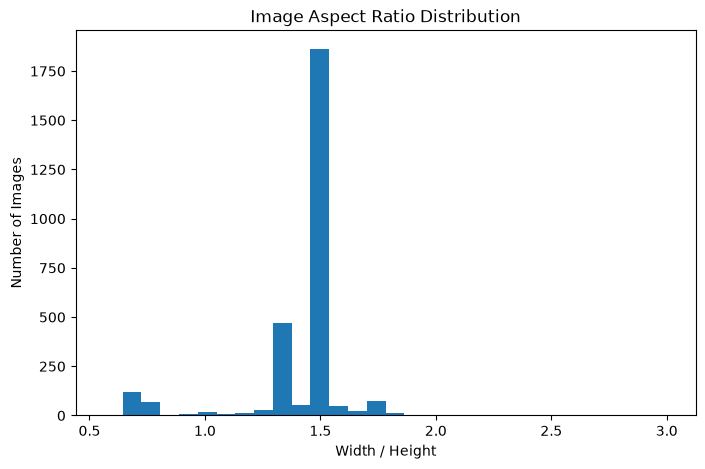

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(aspect_ratios, bins=30)

plt.xlabel("Width / Height")
plt.ylabel("Number of Images")
plt.title("Image Aspect Ratio Distribution")

plt.show()

In [9]:
from collections import Counter

image_modes = Counter()

for image_path in train_images:

    img = Image.open(image_path)

    image_modes[img.mode] += 1

print(image_modes)

Counter({'RGB': 2816})


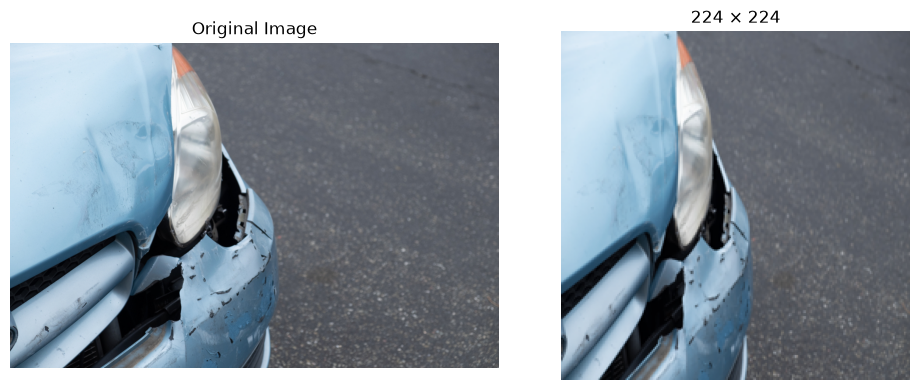

In [10]:
img = Image.open(random.choice(train_images)).convert("RGB")

resized_img = img.resize((224, 224))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_img)
plt.title("224 × 224")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
img_array = np.array(resized_img)

print("Shape:", img_array.shape)
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())
print("Mean pixel value:", img_array.mean())

Shape: (224, 224, 3)
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 125.9872050382653


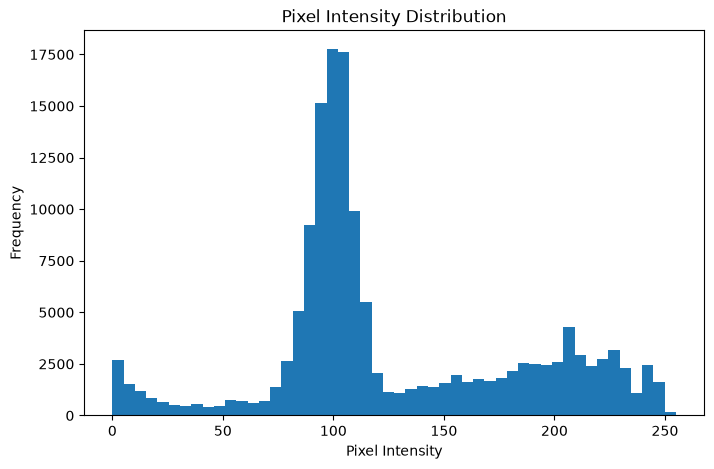

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(img_array.ravel(), bins=50)

plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Distribution")

plt.show()

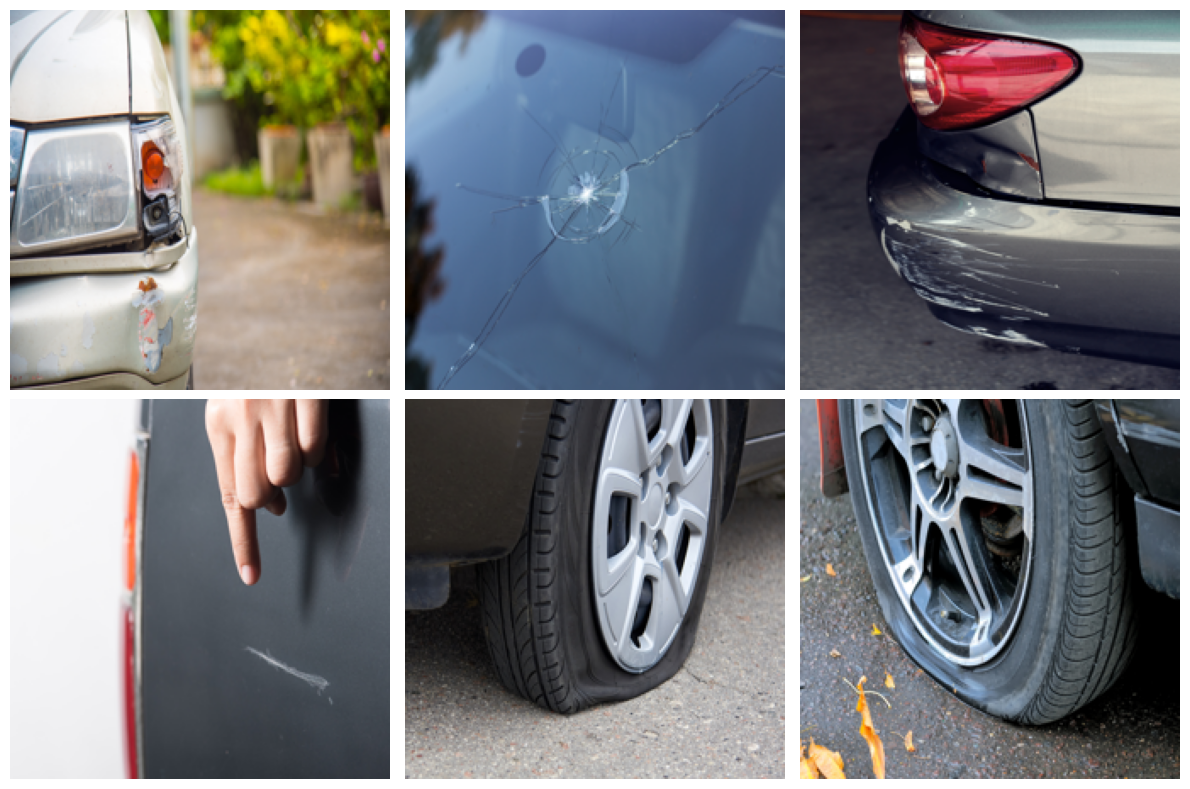

In [13]:
sample_images = random.sample(train_images, 6)

plt.figure(figsize=(12, 8))

for i, image_path in enumerate(sample_images):

    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
corrupted_images = []

for image_path in train_images:

    try:
        img = Image.open(image_path)
        img.verify()

    except Exception:
        corrupted_images.append(image_path)

print("Corrupted training images:", len(corrupted_images))

for image in corrupted_images[:20]:
    print(image)

Corrupted training images: 0


In [15]:
corrupted_val = []

for image_path in val_images:

    try:
        img = Image.open(image_path)
        img.verify()

    except Exception:
        corrupted_val.append(image_path)


corrupted_test = []

for image_path in test_images:

    try:
        img = Image.open(image_path)
        img.verify()

    except Exception:
        corrupted_test.append(image_path)


print("Corrupted validation images:", len(corrupted_val))
print("Corrupted test images:", len(corrupted_test))

Corrupted validation images: 0
Corrupted test images: 0


In [16]:
import json
DATA_ROOT = Path(r"C:\Users\Niraj Mhatre\projects\motor_insurance_data\Data\CarDD_release\CarDD_release")
ANNOTATION_DIR = COCO_DIR / "annotations"

# Load annotation file
annotation_file = ANNOTATION_DIR / "instances_train2017.json"   # replace with your filename

with open(annotation_file, "r") as file:
    data = json.load(file)

# Category dictionary
category_dict = {}

for category in data["categories"]:
    category_dict[category["id"]] = category["name"]

In [17]:
category_images = {}

for annotation in data["annotations"]:

    category_id = annotation["category_id"]
    image_id = annotation["image_id"]

    if category_id not in category_images:
        category_images[category_id] = set()

    category_images[category_id].add(image_id)

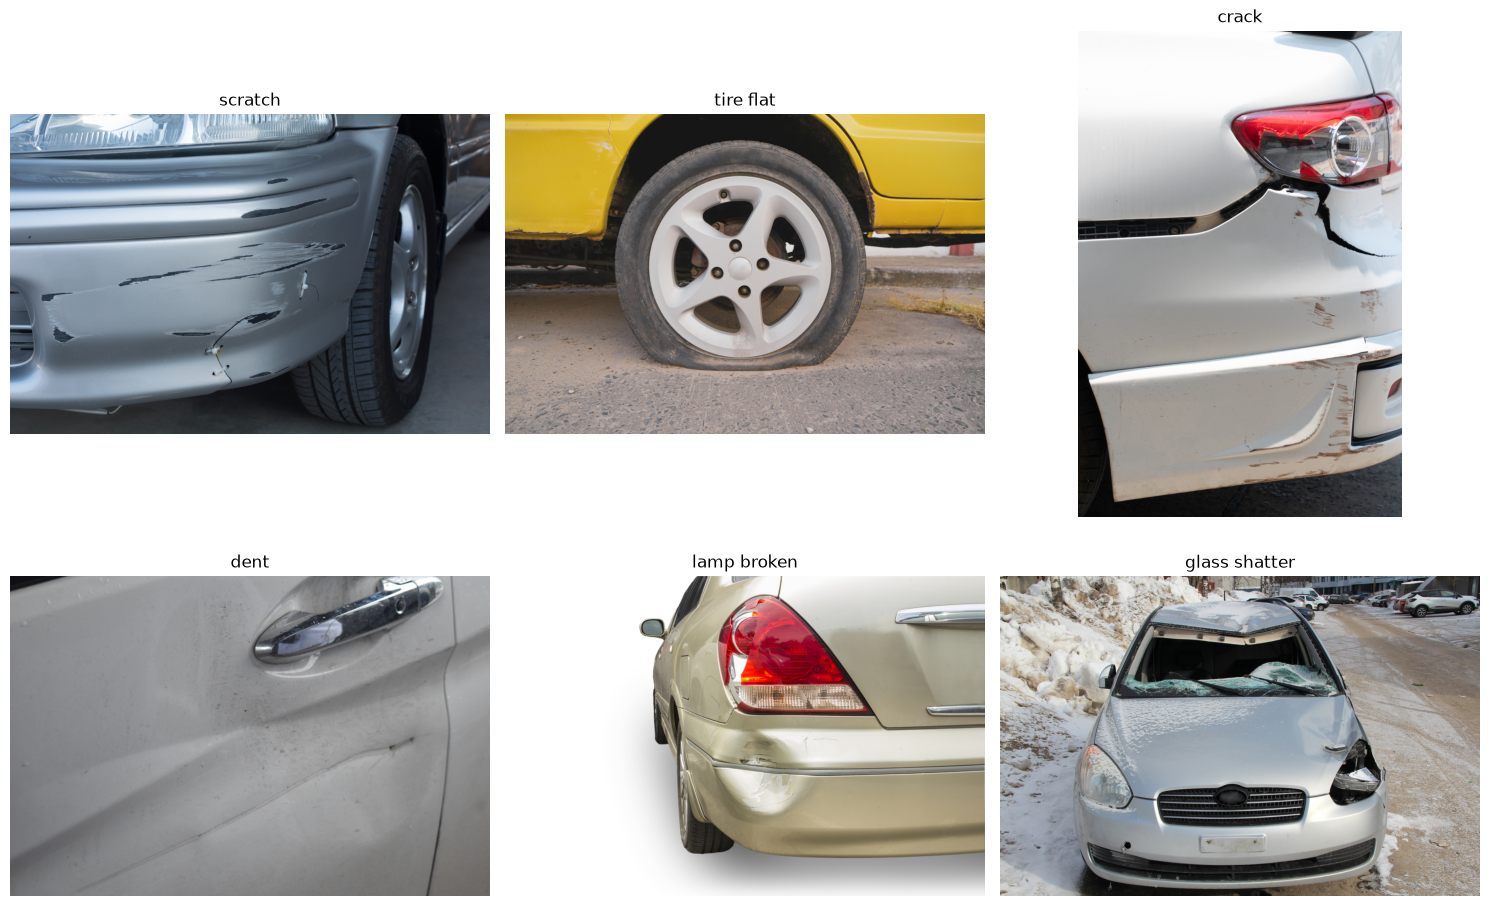

In [18]:
plt.figure(figsize=(15, 10))

category_ids = list(category_images.keys())

for i, category_id in enumerate(category_ids[:6]):

    image_ids_for_category = list(category_images[category_id])

    image_id = random.choice(image_ids_for_category)

    image_info = next(img for img in data["images"] if img["id"] == image_id)
    image_path = TRAIN_DIR / image_info["file_name"]

    img = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)

    plt.title(category_dict[category_id])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
multiple_damage_images = []

damage_per_image = Counter(ann["image_id"] for ann in data["annotations"])

for image_id, count in damage_per_image.items():

    if count > 1:
        multiple_damage_images.append(image_id)

print("Images with multiple annotations:", len(multiple_damage_images))

Images with multiple annotations: 1545


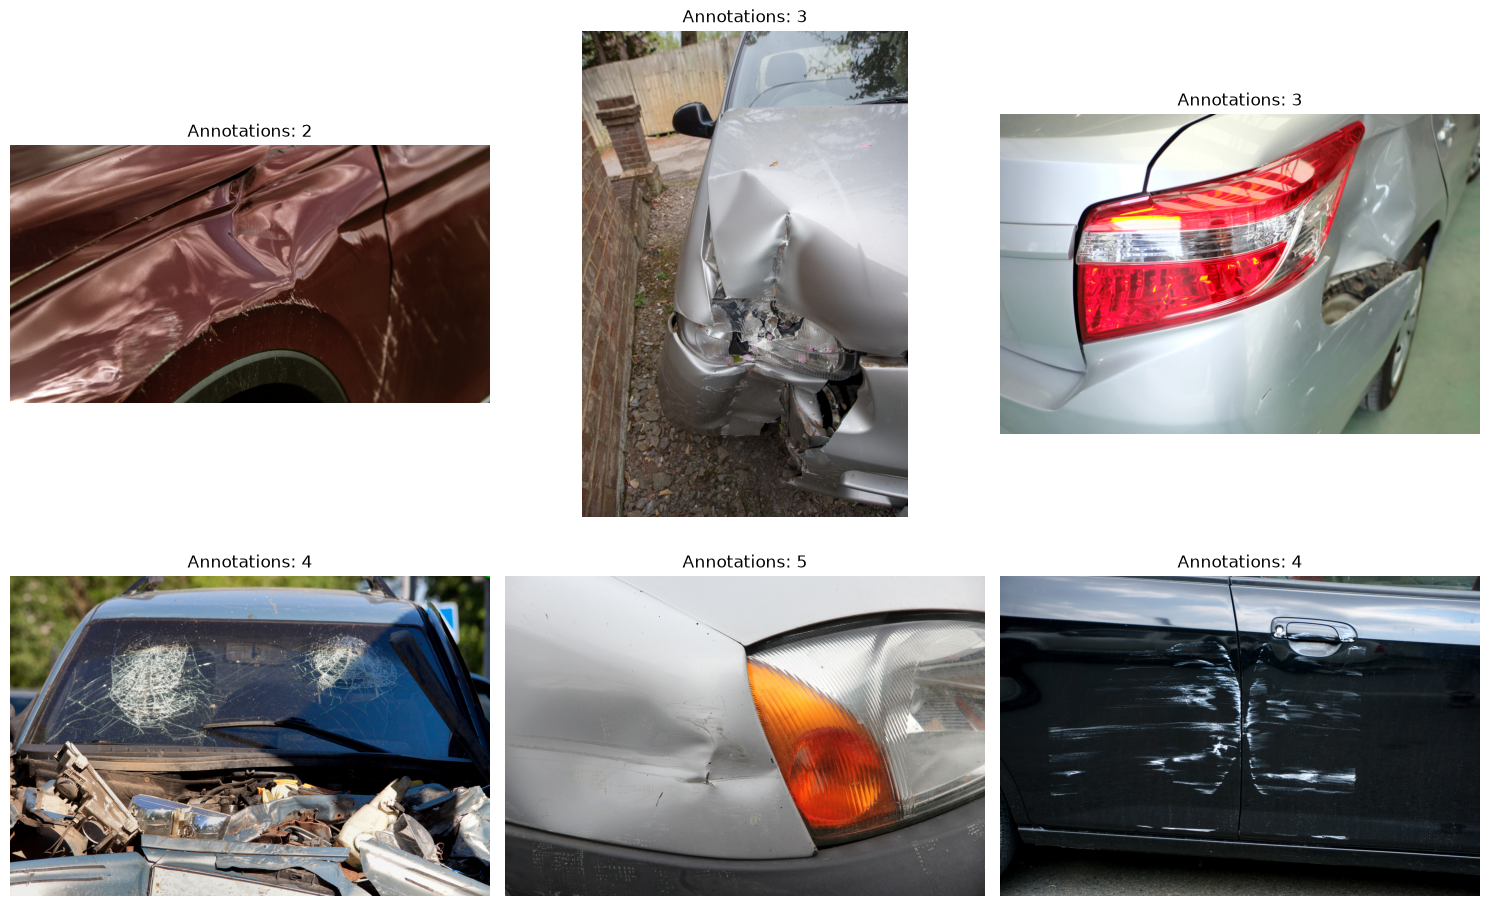

In [20]:
sample_multiple = random.sample(
    multiple_damage_images,
    min(6, len(multiple_damage_images))
)

plt.figure(figsize=(15, 10))

for i, image_id in enumerate(sample_multiple):

    image_info = next(img for img in data["images"] if img["id"] == image_id)
    image_path = TRAIN_DIR / image_info["file_name"]

    img = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)

    plt.title(
        "Annotations: " + str(damage_per_image[image_id])
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
image_area_dict = {img["id"]: img["width"] * img["height"] for img in data["images"]}
relative_damage_areas = [
    ann["area"] / image_area_dict[ann["image_id"]]
    for ann in data["annotations"]
]

small_threshold = np.percentile(
    relative_damage_areas,
    25
)

large_threshold = np.percentile(
    relative_damage_areas,
    75
)

print("Small damage threshold:", small_threshold)
print("Large damage threshold:", large_threshold)

Small damage threshold: 0.011151424287856072
Large damage threshold: 0.13403445210419496


In [22]:
small_damage = []
large_damage = []

bbox_data = [
    {**ann, "relative_damage_area": ann["area"] / image_area_dict[ann["image_id"]]}
    for ann in data["annotations"]
]

for item in bbox_data:

    area = item["relative_damage_area"]

    if area <= small_threshold:
        small_damage.append(item)

    elif area >= large_threshold:
        large_damage.append(item)

print("Small damage examples:", len(small_damage))
print("Large damage examples:", len(large_damage))

Small damage examples: 1554
Large damage examples: 1553


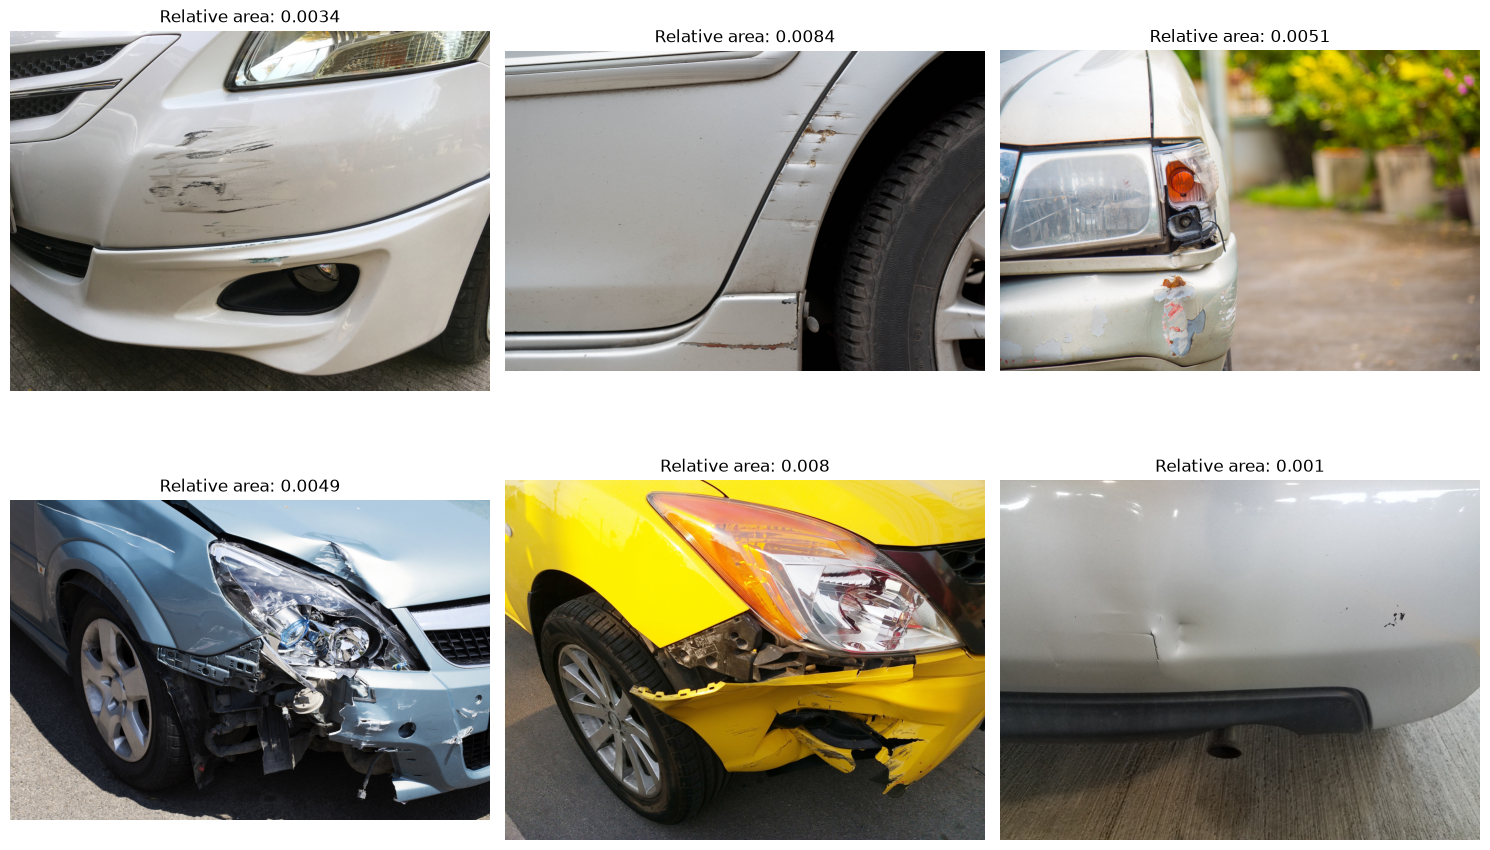

In [23]:
sample_small = random.sample(
    small_damage,
    min(6, len(small_damage))
)

plt.figure(figsize=(15, 10))

for i, item in enumerate(sample_small):

    image_id = item["image_id"]
    image_info = next(img for img in data["images"] if img["id"] == image_id)
    image_path = TRAIN_DIR / image_info["file_name"]

    img = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)

    plt.title(
        "Relative area: "
        + str(round(item["relative_damage_area"], 4))
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
def preprocess_image(image_path):

    img = Image.open(image_path)

    # Convert to RGB
    img = img.convert("RGB")

    # Resize
    img = img.resize((224, 224))

    # Convert to numpy array
    img = np.array(img)

    # Scale pixel values to 0-1
    img = img / 255.0

    return img

In [25]:
sample_path = random.choice(train_images)

processed_img = preprocess_image(sample_path)

print("Shape:", processed_img.shape)
print("Minimum:", processed_img.min())
print("Maximum:", processed_img.max())

Shape: (224, 224, 3)
Minimum: 0.0
Maximum: 1.0


In [27]:

import torch
from torchvision import transforms

In [28]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(
        224,
        scale=(0.9, 1.0)
    ),
    transforms.ColorJitter(
        brightness=0.1
    ),
    transforms.ToTensor()
])

In [29]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [30]:
sample_path = random.choice(train_images)

img = Image.open(sample_path).convert("RGB")

transformed_img = train_transform(img)

print("Shape:", transformed_img.shape)
print("Minimum:", transformed_img.min())
print("Maximum:", transformed_img.max())

Shape: torch.Size([3, 224, 224])
Minimum: tensor(0.)
Maximum: tensor(0.9451)


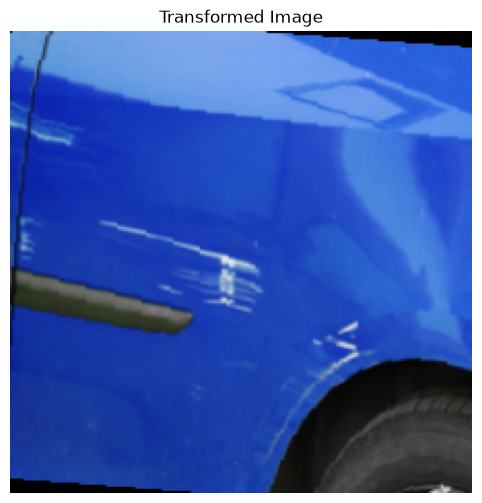

In [31]:
transformed_display = transformed_img.permute(1, 2, 0)

plt.figure(figsize=(6, 6))

plt.imshow(transformed_display)

plt.axis("off")
plt.title("Transformed Image")

plt.show()

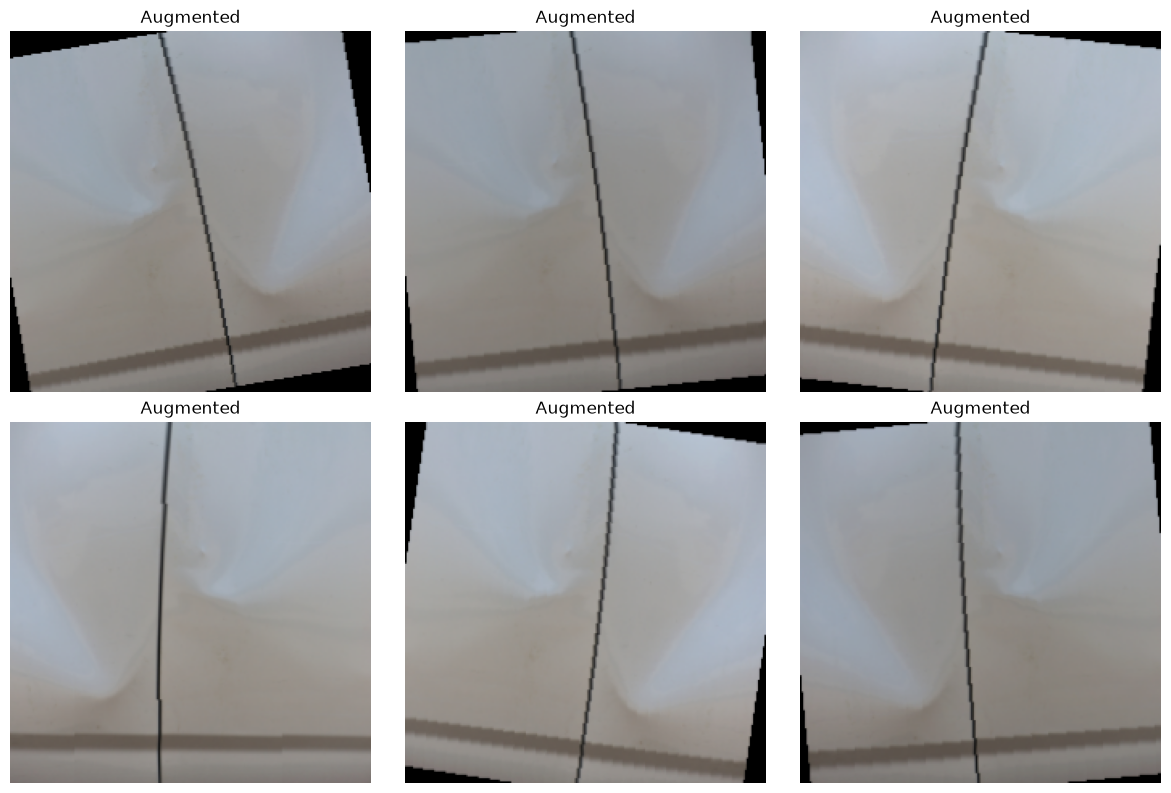

In [32]:
sample_path = random.choice(train_images)

img = Image.open(sample_path).convert("RGB")

plt.figure(figsize=(12, 8))

for i in range(6):

    transformed_img = train_transform(img)

    transformed_img = transformed_img.permute(1, 2, 0)

    plt.subplot(2, 3, i + 1)
    plt.imshow(transformed_img)
    plt.axis("off")
    plt.title("Augmented")

plt.tight_layout()
plt.show()

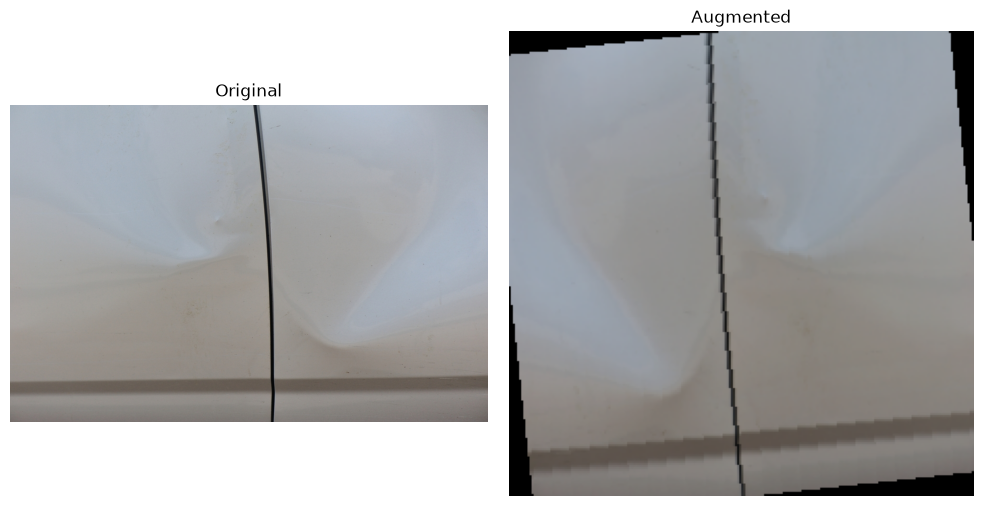

In [33]:
img = Image.open(sample_path).convert("RGB")

augmented_img = train_transform(img)

augmented_img = augmented_img.permute(1, 2, 0)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(img)
plt.title("Original")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(augmented_img)
plt.title("Augmented")
plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

In [35]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(
        224,
        scale=(0.9, 1.0)
    ),
    transforms.ColorJitter(
        brightness=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

In [36]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

In [37]:
sample_path = random.choice(train_images)

img = Image.open(sample_path).convert("RGB")

tensor_img = val_test_transform(img)

print("Shape:", tensor_img.shape)
print("Minimum:", tensor_img.min())
print("Maximum:", tensor_img.max())

Shape: torch.Size([3, 224, 224])
Minimum: tensor(-2.0494)
Maximum: tensor(2.4657)


In [38]:
sample_path = random.choice(train_images)

img = Image.open(sample_path).convert("RGB")

train_tensor = train_transform(img)
test_tensor = val_test_transform(img)

print("Original size:", img.size)

print("Training tensor shape:", train_tensor.shape)
print("Validation/Test tensor shape:", test_tensor.shape)

print("Training tensor dtype:", train_tensor.dtype)
print("Validation/Test tensor dtype:", test_tensor.dtype)

Original size: (1000, 667)
Training tensor shape: torch.Size([3, 224, 224])
Validation/Test tensor shape: torch.Size([3, 224, 224])
Training tensor dtype: torch.float32
Validation/Test tensor dtype: torch.float32
